In [84]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

custo = [0, 1, 1.2, 1.3, 1.4, 1.5, 1.6, 3, 4, 5, 6]

diretorio = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/"

df_all = pd.DataFrame()
df_processed = []

for c in custo:
    diretorio = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/custo_raio_{c}/"
    df = pd.read_csv(os.path.join(diretorio, "resultados.csv"))
    df["custo"] = c
    df_all = pd.concat([df_all, df], ignore_index=True)

    media = df.groupby(["t"])[["freq_O", "freq_B", "freq_Y", "r_O", "r_Y", "r_B"]].mean().reset_index()
    media = media.rename(columns={
    "freq_O": "freq_O_mean",
    "freq_Y": "freq_Y_mean",
    "freq_B": "freq_B_mean",
    "r_O": "r_O_mean",
    "r_Y": "r_Y_mean",
    "r_B": "r_B_mean"
    })
    sd = df.groupby(["t"])[["freq_O", "freq_B", "freq_Y", "r_O", "r_Y", "r_B"]].std().reset_index()
    sd = sd.rename(columns={
    "freq_O": "freq_O_std",
    "freq_Y": "freq_Y_std",
    "freq_B": "freq_B_std",
    "r_O": "r_O_std",
    "r_Y": "r_Y_std",
    "r_B": "r_B_std"
    })
    media = media.merge(sd, on=["t"], how="left")
    media["custo"] = c
    df_processed.append(media)

df_processed = pd.concat(df_processed, ignore_index=True)
print(df_processed)


        t  freq_O_mean  freq_B_mean  freq_Y_mean  r_O_mean  r_Y_mean  \
0      -1     0.333609     0.333125     0.333266  4.501659  4.500760   
1       0     0.333051     0.331986     0.334963  7.995112  7.994897   
2       1     0.327265     0.337622     0.335113  7.989110  7.991285   
3       2     0.328329     0.341743     0.329928  7.986983  7.988875   
4       3     0.339258     0.338704     0.322038  7.985458  7.984609   
...   ...          ...          ...          ...       ...       ...   
5506  495     0.334870     0.331447     0.333683  1.005059  1.004779   
5507  496     0.334602     0.331231     0.334167  1.004809  1.004977   
5508  497     0.334078     0.331315     0.334607  1.005165  1.004929   
5509  498     0.334024     0.331225     0.334751  1.005011  1.004882   
5510  499     0.333730     0.331247     0.335023  1.004736  1.005066   

      r_B_mean  freq_O_std  freq_B_std  freq_Y_std   r_O_std   r_Y_std  \
0     4.503656    0.004890    0.004521    0.004416  0.038753 

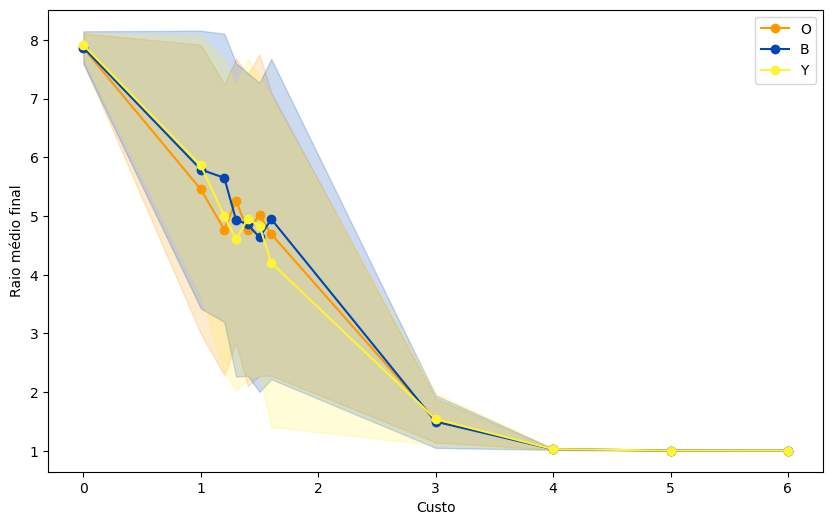

In [85]:
ultima_geracao = df_processed[df_processed["t"] == df_processed["t"].max()]
ultima_geracao

cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

plt.figure(figsize=(10, 6))
plt.plot(ultima_geracao["custo"], ultima_geracao["r_O_mean"], label="O", color=cores["O"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["r_O_mean"] - ultima_geracao["r_O_std"],
                 ultima_geracao["r_O_mean"] + ultima_geracao["r_O_std"],
                 color=cores["O"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["r_B_mean"], label="B", color=cores["B"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["r_B_mean"] - ultima_geracao["r_B_std"],
                 ultima_geracao["r_B_mean"] + ultima_geracao["r_B_std"],
                 color=cores["B"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["r_Y_mean"], label="Y", color=cores["Y"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["r_Y_mean"] - ultima_geracao["r_Y_std"],
                 ultima_geracao["r_Y_mean"] + ultima_geracao["r_Y_std"],
                 color=cores["Y"], alpha=0.2)
plt.xlabel("Custo")
plt.ylabel("Raio médio final")
plt.legend()
plt.savefig(os.path.join(diretorio, "custo_raio.png"))
plt.show()

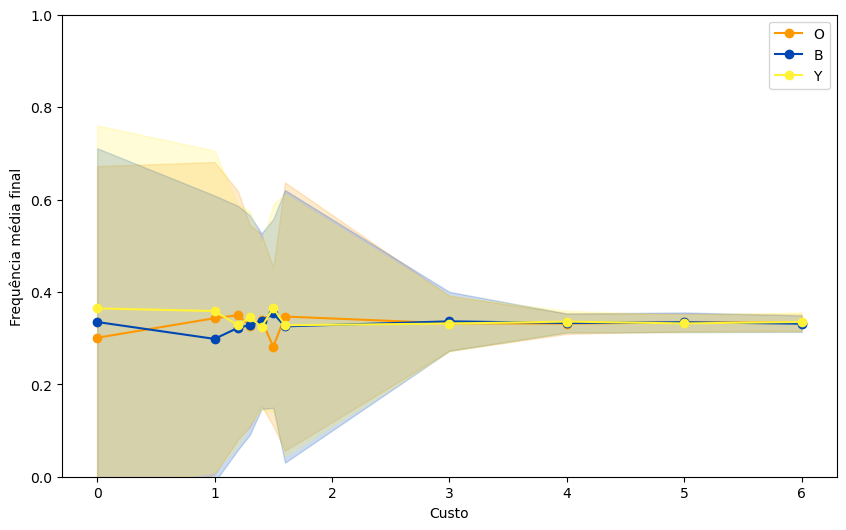

In [86]:
plt.figure(figsize=(10, 6))
plt.plot(ultima_geracao["custo"], ultima_geracao["freq_O_mean"], label="O", color=cores["O"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["freq_O_mean"] - ultima_geracao["freq_O_std"],
                 ultima_geracao["freq_O_mean"] + ultima_geracao["freq_O_std"],
                 color=cores["O"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["freq_B_mean"], label="B", color=cores["B"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["freq_B_mean"] - ultima_geracao["freq_B_std"],
                 ultima_geracao["freq_B_mean"] + ultima_geracao["freq_B_std"],
                 color=cores["B"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["freq_Y_mean"], label="Y", color=cores["Y"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["freq_Y_mean"] - ultima_geracao["freq_Y_std"],
                 ultima_geracao["freq_Y_mean"] + ultima_geracao["freq_Y_std"],
                 color=cores["Y"], alpha=0.2)
plt.xlabel("Custo")
plt.ylabel("Frequência média final")
plt.ylim(0, 1)
plt.legend()
plt.savefig(os.path.join(diretorio, "custo_freq.png"))
plt.show()

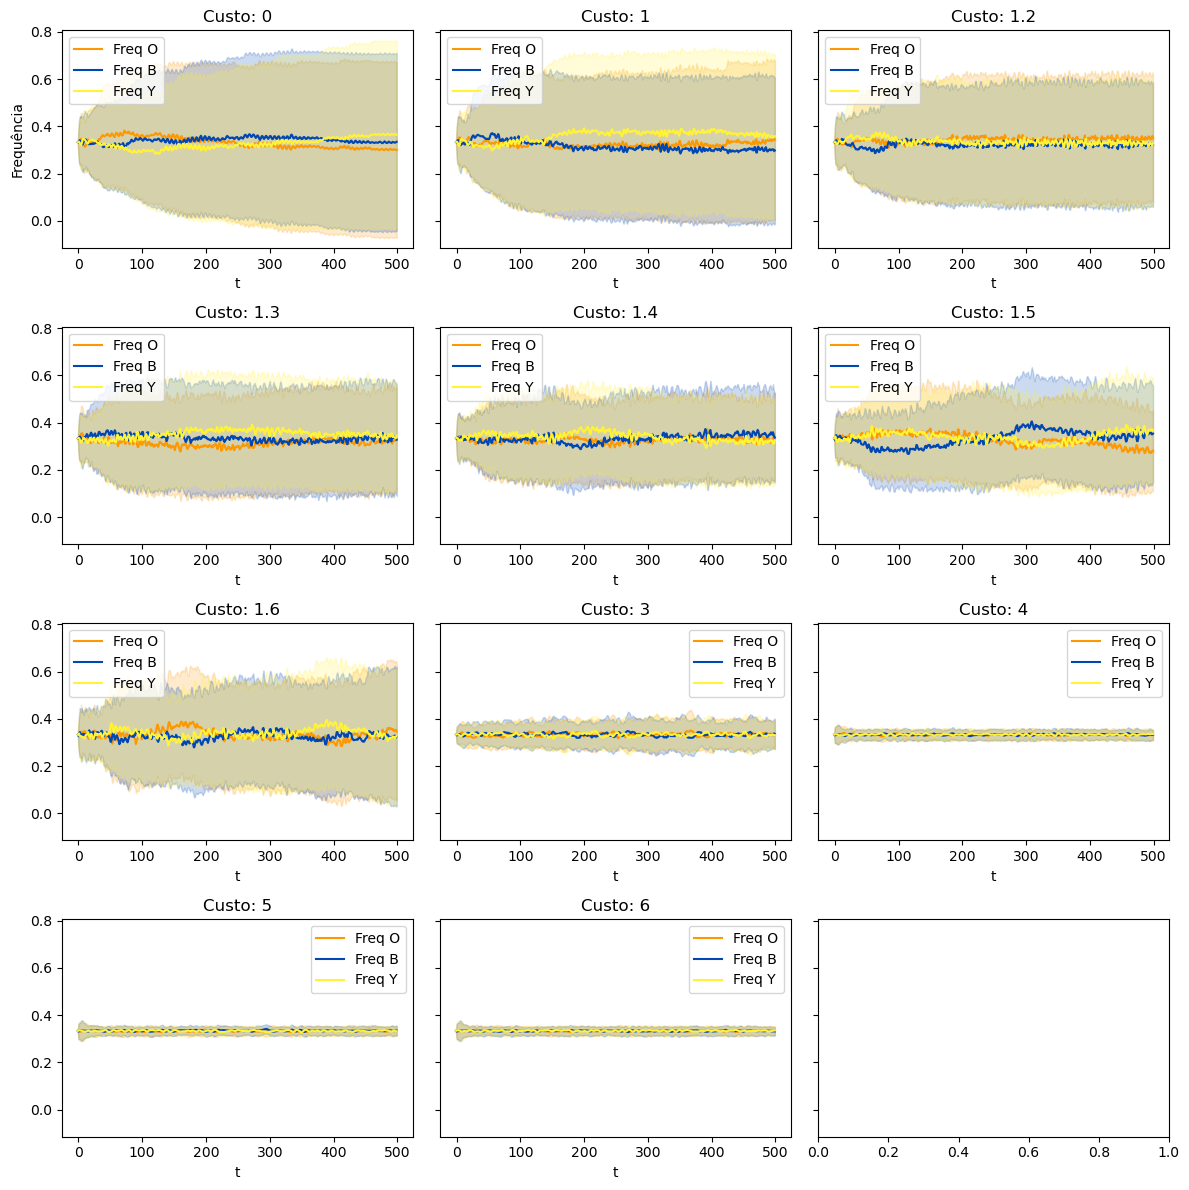

In [87]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

fig, axes = plt.subplots(4, 3, figsize=(12, 12), sharey=True)

for idx, c in enumerate(custo):
    ax = axes[idx//3, idx%3]
    df_c = df_processed[df_processed["custo"] == c]
    for cor in ["O", "B", "Y"]:
        ax.plot(df_c["t"], df_c[f"freq_{cor}_mean"], label=f"Freq {cor}", color=cores[cor])
        ax.fill_between(df_c["t"],
                        df_c[f"freq_{cor}_mean"] - df_c[f"freq_{cor}_std"],
                        df_c[f"freq_{cor}_mean"] + df_c[f"freq_{cor}_std"],
                        color=cores[cor], alpha=0.2)
    ax.set_title(f"Custo: {c}")
    ax.set_xlabel("t")
    if idx == 0:
        ax.set_ylabel("Frequência")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(diretorio, "custo_freq_grid.png"))
plt.show()

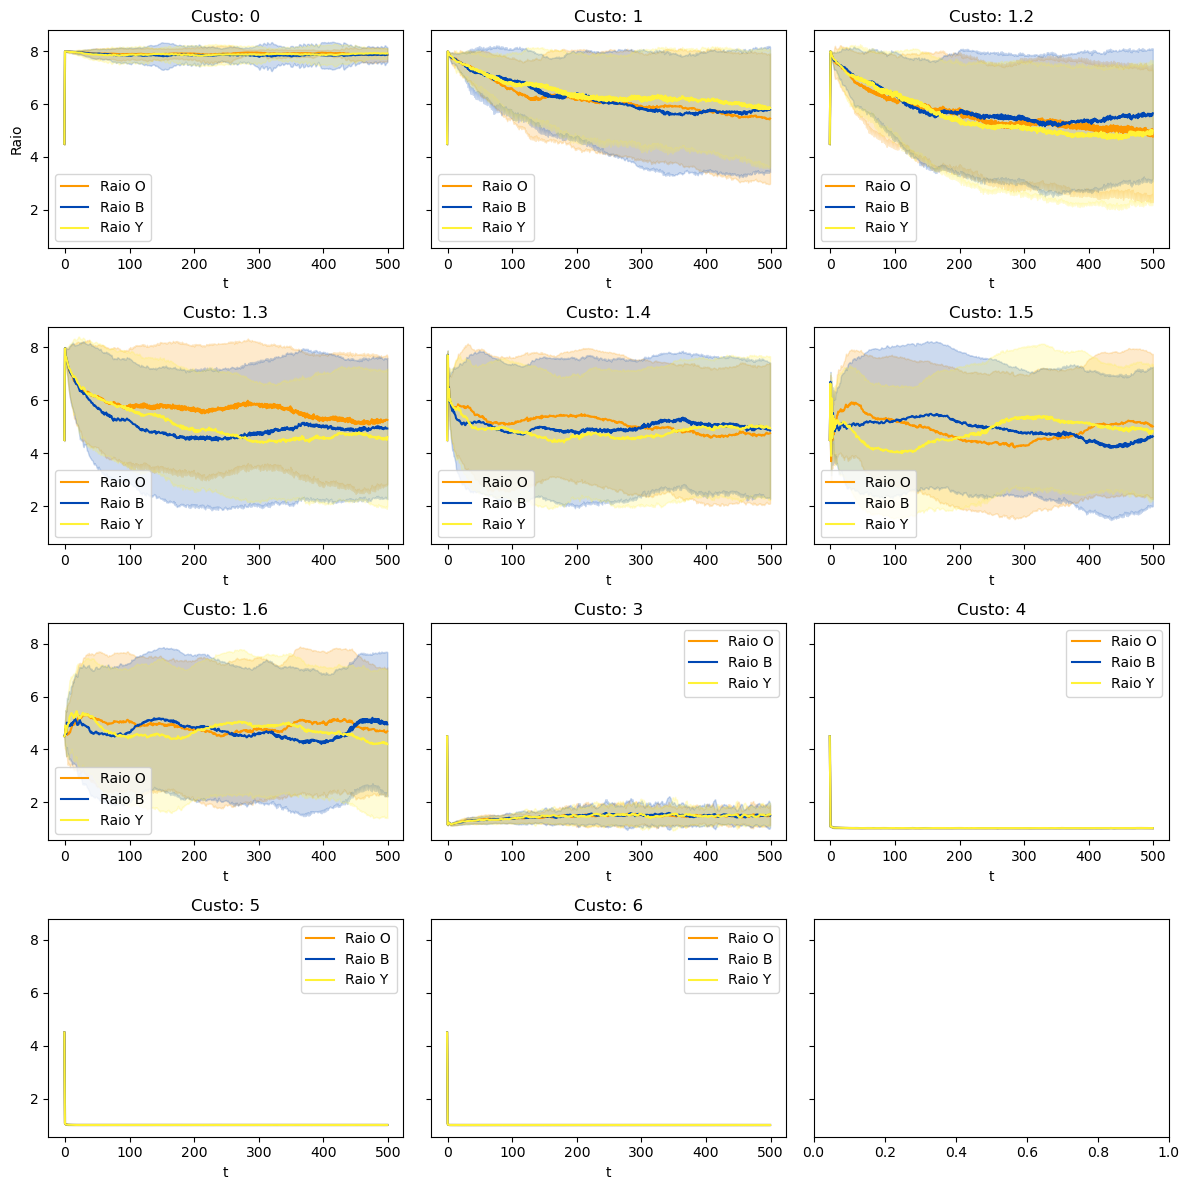

In [88]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

fig, axes = plt.subplots(4, 3, figsize=(12, 12), sharey=True)

for idx, c in enumerate(custo):
    ax = axes[idx//3, idx%3]
    df_c = df_processed[df_processed["custo"] == c]
    for cor in ["O", "B", "Y"]:
        ax.plot(df_c["t"], df_c[f"r_{cor}_mean"], label=f"Raio {cor}", color=cores[cor])
        ax.fill_between(df_c["t"],
                        df_c[f"r_{cor}_mean"] - df_c[f"r_{cor}_std"],
                        df_c[f"r_{cor}_mean"] + df_c[f"r_{cor}_std"],
                        color=cores[cor], alpha=0.2)
    ax.set_title(f"Custo: {c}")
    ax.set_xlabel("t")
    if idx == 0:
        ax.set_ylabel("Raio")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(diretorio, "custo_raio_grid.png"))
plt.show()